<span style="color: #FF63BF; font-size: 30px;"> WICDS Data Science Committee Project - Education & Population </span>

## Are global years of education and number of out of school children correlated?

### By: Shreya Chittipeddi

<span style="color: #FF63BF; font-size: 25px;"> Hypothesis: The number of out of school children and the average time spent in school are negatively correlated globally. </span>

In [29]:
# Run this cell to set up your notebook
import numpy as np
import pandas as pd
import datetime
import folium
import ipywidgets as widgets
from IPython.display import display, HTML

import datascience
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
%matplotlib inline

<span style="color: #FF63BF; font-size: 25px;"> Data Sets </span>

<span style="color: #A86DBF; font-size: 15px;"> My first data set contains data from different countries globally about the number of male and female children that are out of school. The data set contains the country name, country code, year, male students out of school, and female students out of school. </span>

https://www.kaggle.com/datasets/imtkaggleteam/global-education/data

In [16]:
children = pd.read_csv("3- number-of-out-of-school-children.csv")  

<span style="color: #A86DBF; font-size: 15px;"> My second data set contains data from different countries globally about the average number of years of schooling people in each specific country have. The data set contains the country name, country code, year, and number of years of schooling.  </span>

In [17]:
education = pd.read_csv("2- learning-adjusted-years-of-school-lays.csv")

<span style="color: #FF63BF; font-size: 25px;"> Data Cleaning </span>

The goal of my two data sets was to find a correlation between the number of children out of school versus its average school years completed by its citizens. To do this I wanted to find columns that were similar between them while getting rid of the country code because it was not necessary for my data. 

In [18]:
children = children.drop(columns = ["Code"])
children

,Entity,Year,"Out-of-school children, adolescents and youth of primary and secondary school age, male (number)","Out-of-school children, adolescents and youth of primary and secondary school age, female (number)"
0,Albania,2000,78614.0,81341.0
1,Albania,2001,77837.0,78849.0
2,Albania,2013,27879.0,21727.0
3,Albania,2014,21542.0,16571.0
4,Albania,2015,18407.0,13250.0
...,...,...,...,...
2575,Zimbabwe,2001,386981.0,474012.0
2576,Zimbabwe,2002,462514.0,550123.0
2577,Zimbabwe,2003,522317.0,600606.0
2578,Zimbabwe,2012,284958.0,333954.0


In [19]:
education = education.drop(columns = ["Code"])
education

,Entity,Year,Learning-Adjusted Years of School
0,Afghanistan,2017,4.870000
1,Afghanistan,2018,4.949788
2,Afghanistan,2020,5.052838
3,Africa,2017,4.931378
4,Africa,2018,5.123904
...,...,...,...
632,Zambia,2020,5.036293
633,Zimbabwe,2010,6.835774
634,Zimbabwe,2017,6.350000
635,Zimbabwe,2018,7.006610


#### I also decided to rename the proportions in the pop data frame to "Proportion With Formal Education" and "Proportion Without Formal Education" for simplicity and readability. I also decided to rename the last column in the education data frame to "Years in School".

In [20]:
children.rename(columns = {"Out-of-school children, adolescents and youth of primary and secondary school age, male (number)": "Male Out of School Children", "Out-of-school children, adolescents and youth of primary and secondary school age, female (number)": "Female Out of School Children"}, inplace = True)
children

,Entity,Year,Male Out of School Children,Female Out of School Children
0,Albania,2000,78614.0,81341.0
1,Albania,2001,77837.0,78849.0
2,Albania,2013,27879.0,21727.0
3,Albania,2014,21542.0,16571.0
4,Albania,2015,18407.0,13250.0
...,...,...,...,...
2575,Zimbabwe,2001,386981.0,474012.0
2576,Zimbabwe,2002,462514.0,550123.0
2577,Zimbabwe,2003,522317.0,600606.0
2578,Zimbabwe,2012,284958.0,333954.0


In [21]:
education.rename(columns = {"Learning-Adjusted Years of School": "Years in School"}, inplace = True)
education

,Entity,Year,Years in School
0,Afghanistan,2017,4.870000
1,Afghanistan,2018,4.949788
2,Afghanistan,2020,5.052838
3,Africa,2017,4.931378
4,Africa,2018,5.123904
...,...,...,...
632,Zambia,2020,5.036293
633,Zimbabwe,2010,6.835774
634,Zimbabwe,2017,6.350000
635,Zimbabwe,2018,7.006610


<span style="color: #FF63BF; font-size: 25px;"> EDA </span>

#### Now that the two dataframes have been cleaned for easier visualization, I will now merge the "Entity" and "Year" columns that are shared in both dataframes. 

In [22]:
data = pd.merge(children, education, on = ['Entity', 'Year'])
data

,Entity,Year,Male Out of School Children,Female Out of School Children,Years in School
0,Albania,2017,20594.0,11519.0,8.920000
1,Albania,2018,21066.0,9505.0,8.851396
2,Antigua and Barbuda,2018,288.0,208.0,8.093484
3,Argentina,2010,276512.0,142669.0,8.238216
4,Argentina,2017,157961.0,80216.0,8.870000
...,...,...,...,...,...
221,United Kingdom,2018,83413.0,79306.0,11.457277
222,United States,2010,1021515.0,867755.0,10.352440
223,United States,2017,422042.0,314850.0,11.140000
224,United States,2018,344551.0,289900.0,10.779745


#### Now that I have one data frame for my data, I will create visualizations for years in school and children out of school globally based on the year. 

<function matplotlib.pyplot.show(close=None, block=None)>

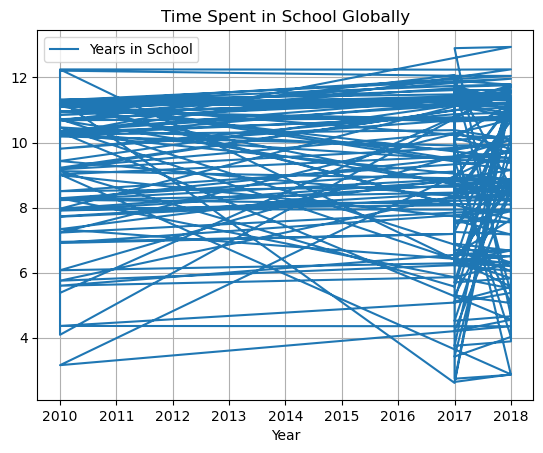

In [23]:
data.plot(x = 'Year', y = 'Years in School', kind = 'line', title = 'Time Spent in School Globally', grid = True)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

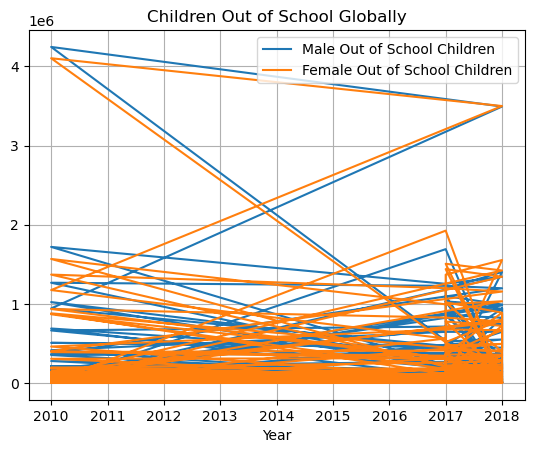

In [24]:
data.plot(x = 'Year', y = ['Male Out of School Children', 'Female Out of School Children'], kind = 'line', title = 'Children Out of School Globally', grid = True)
plt.show

#### As you can see, due to the vast number of countries in the data set, simply the process of EDA is not enough to make a claim. Thus, I will use linear regression to observe the correlation between out-of-school children and years in school globally. Since I am working with numerical and not categorical data, I used regression instead of classification. 

<span style="color: #FF63BF; font-size: 25px;"> Modeling and Model Evaluation </span>

#### I will use linear regression to compare the amount of time spent in school to male out of school children across all time globally. To do this I made my x-variable "Years in School" and my y-variable "Male Out of School Children". Since the data had multiple columns I reshaped my values to make it more comparable for regression. I then used the LinearRegression() and predict() functions to illustrate this relationship between the two variables. Then I created a scatter plot to show the two variables being plotted and a plot to illustrate the regression. I used aesthetic mapping to add an informative title, add axis labels, and add color for easy comparison. 

#### Based on the visualization below, the linear regression generally fits the points well however there are many countries which have noticeable outliers on this graph around 8-9 years in school for 1-4 million boys in school which indiciates that the linear regression does not account for this noticeable pattern.

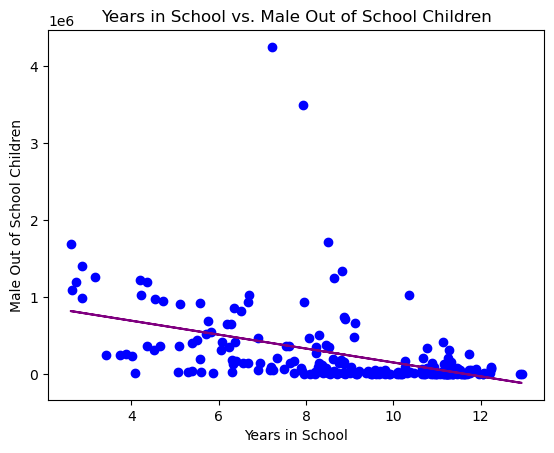

In [25]:
X = data.iloc[:, 4].values.reshape(-1,1)
Y = data.iloc[:, 2].values.reshape(-1,1)

linear_regressor = LinearRegression()
linear_regressor.fit(X, Y)
Y_pred = linear_regressor.predict(X)

plt.scatter(X, Y, color = 'blue')
plt.plot(X, Y_pred, color = 'purple')
plt.title('Years in School vs. Male Out of School Children')
plt.xlabel('Years in School')
plt.ylabel('Male Out of School Children')
plt.show()

#### I will then use linear regression again to compare the amount of time spent in school to female out of school children across all time globally. To do this I made my x-variable "Years in School" and my y-variable "Female Out of School Children". Since the data had multiple columns I reshaped my values to make it more comparable for regression. I then used the LinearRegression() and predict() functions to illustrate this relationship between the two variables. Then I created a scatter plot to show the two variables being plotted and a plot to illustrate the regression. I used aesthetic mapping to add an informative title, add axis labels, and add color for easy comparison. 

#### Based on the visualization below, the linear regression generally fits the points well however, just like for male out of school children, there are many countries which have noticeable outliers on this graph around 8-9 years in school for 1-4 million girls in school which indiciates that the linear regression does not account for this noticeable pattern.

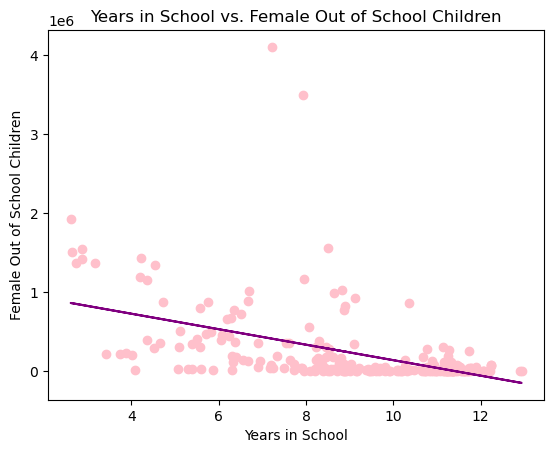

In [26]:
X = data.iloc[:, 4].values.reshape(-1,1)
Y = data.iloc[:, 3].values.reshape(-1,1)

linear_regressor = LinearRegression()
linear_regressor.fit(X, Y)
Y_pred = linear_regressor.predict(X)

plt.scatter(X, Y, color = 'pink')
plt.plot(X, Y_pred, color = 'purple')
plt.title('Years in School vs. Female Out of School Children')
plt.xlabel('Years in School')
plt.ylabel('Female Out of School Children')
plt.show()

#### After performing linear regression for both male and female out-of-school children, I am left with two plots. However going back to my hypothesis, I want to compare the relationship of all out-of-school children to years spent in school. Therefore I have to combine the male and female columns to create one column for linear regression. So, I create a column called 'Total Out of School Children' and reshape the values so that I can compare it to 'Years in School'. Then I used the linear regression functions and aesthetic mappings to create a visualization.

#### Based on the visualization below, the pattern seems to be the same as the two plots above in the case that there are noticeable outliers around 8-10 years of school for all children. This indicates that while the linear regression fits the data well, there is an outlier to take into consideration.

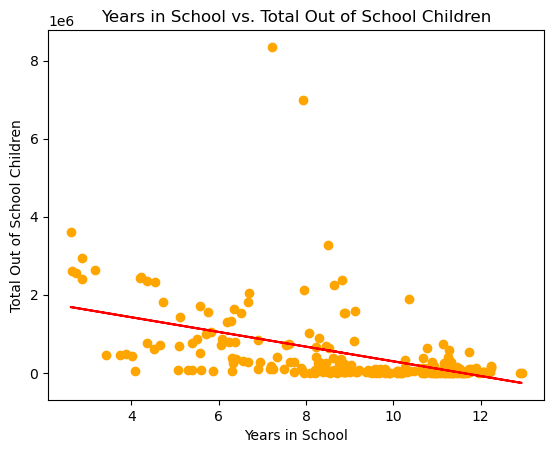

In [27]:
data['Total Out of School Children'] = data.iloc[:, 2] + data.iloc[:, 3]
X = data.iloc[:, 4].values.reshape(-1,1)
Y = data['Total Out of School Children'].values.reshape(-1,1)

linear_regressor = LinearRegression()
linear_regressor.fit(X, Y)
Y_pred = linear_regressor.predict(X)

plt.scatter(X, Y, color = 'orange')
plt.plot(X, Y_pred, color = 'red')
plt.title('Years in School vs. Total Out of School Children')
plt.xlabel('Years in School')
plt.ylabel('Total Out of School Children')
plt.show()

<span style="color: #FF63BF; font-size: 25px;"> Correlation </span>

In [28]:
total = data.loc[data['Total Out of School Children'].notna()]
total = total.loc[(total['Total Out of School Children'] > 0)]
total = total.loc[(total['Years in School'] > 0)]

columns = ['Years in School', 'Total Out of School Children']
corr = total[columns].corr()
corr

,Years in School,Total Out of School Children
Years in School,1.000000,-0.475304
Total Out of School Children,-0.475304,1.000000


#### Correlation is also represented using the value r. Correlation is measured using values from -1 to 1. A value closer to -1 is strongly negative and a value closer to 1 is strongly positive. After calculating the correlation, we get a value of -0.47 which means that there is a medium negative correlation between years in school and total out of school children. This means that we can say there is a negative correlation between the years in school and total out of school children which proves our hypothesis correct. 

<span style="color: #FF63BF; font-size: 25px;"> Conclusion </span>

#### I chose this project topic because I am interested in education and fascinated in seeing how different countries are impacted by education, or a lack of education. I also wanted to see if the amount of time children spend in school is correlated to the number of children who are out of school. By figuring out this correlation, we can see exactly when children tend to leave school so that changes can be made to support higher education.

#### Based on the results of linear regression and the data visualizations, I can see that children tend to spend 8-10 years in school and not the traditional 12 years. Additionally, the correlation value of -0.47 indicates that there is a medium negative correlation, which supports the hypothesis. While we can't claim causality, we can see that as the number of years in school increases, so does the number of children out of school. Therefore there is a negative association with the two. 

#### Using this information, actions can be taken to encourage more children to stay in school for the full 12 years. Policy changes can be made to encourage children to not drop out. Additionally, many children cannot go to school because of financial situations, supporting their families, or distance. Some solutions could be implementing online or remote learning and providing families with technology, making more public schools, and jobs encouraging part-time work to support education.